Nom : KARBOUN Ahmed Master : GLCC

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PROBLEME MATHEMATIQUE
# ------------------------------------------------------------
# On cherche à apprendre une fonction non linéaire :
# y = W0 + W1*x1 + W2*x2^2 + W3*x3^3 + W4*x4^4 + W5*x5^5 + W6*x6^6
#
# Formule des moindres carrés (Normal Equation) :
# W = (X^T X)^(-1) X^T y
# ------------------------------------------------------------


In [35]:
# ------------------------------------------------------------
# 2. DATASET (Exemple de données d'étudiants)
# ------------------------------------------------------------
heures_etude  = np.array([2, 4, 6, 8, 10, 3, 7])
sommeil       = np.array([5, 6, 7, 7, 8, 4, 6])
stress        = np.array([8, 6, 5, 4, 3, 9, 5])
participation = np.array([20, 40, 60, 80, 90, 30, 70])
sport         = np.array([0, 2, 3, 4, 5, 0, 3])
ecran         = np.array([6, 5, 4, 3, 2, 7, 4])

# Cible : La note finale (sur 20)
y = np.array([10, 13, 15, 17, 18.5, 11, 16]).reshape(-1, 1)


In [36]:
# ------------------------------------------------------------
# 3. MATRICE DE CARACTERISTIQUES (FEATURE MATRIX)
# ------------------------------------------------------------
X = np.column_stack([
    heures_etude,
    sommeil**2,
    stress**3,
    participation**4,
    sport**5,
    ecran**6
])

# Ajout du biais (la colonne de 1 pour l'ordonnée à l'origine W0)
X_b = np.column_stack([np.ones(X.shape[0]), X])


In [37]:
# ------------------------------------------------------------
# 4. ENTRAÎNEMENT
# ------------------------------------------------------------
# Utilisation de la pseudo-inverse pour la stabilité numérique
W = np.linalg.pinv(X_b) @ y



--- SAISIE DES DONNÉES POUR PRÉDICTION ---

--- RÉSULTAT ---
Note prédite : 11.69 / 20


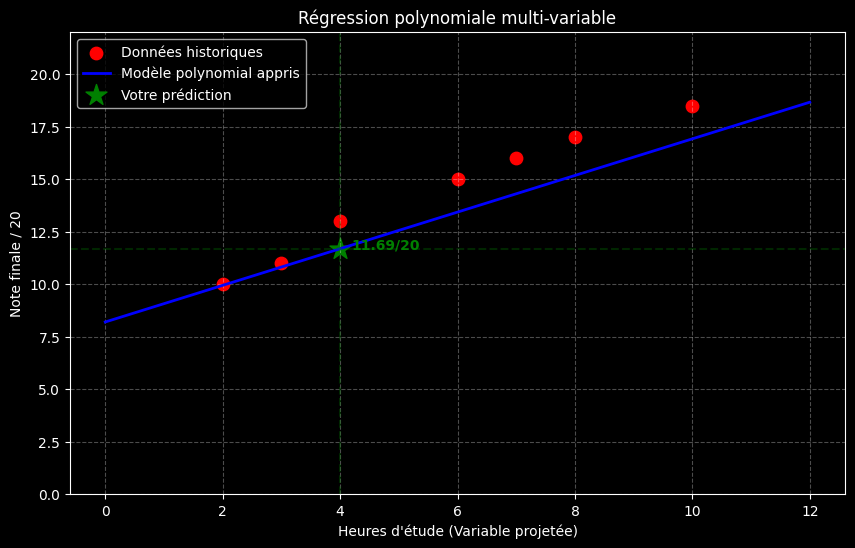

In [38]:
# ------------------------------------------------------------
# 5. SAISIE UTILISATEUR
# ------------------------------------------------------------
print("\n--- SAISIE DES DONNÉES POUR PRÉDICTION ---")
u1 = float(input("Heures d'étude : ")) #demande à l'utilisateur de saisir les heures d'étude
u2 = float(input("Heures de sommeil : ")) #demande à l'utilisateur de saisir les heures de sommeil
u3 = float(input("Niveau de stress (1-10) : ")) #demande à l'utilisateur de saisir le niveau de stress
u4 = float(input("Participation (%) : ")) #demande à l'utilisateur de saisir le pourcentage de participation en classe
u5 = float(input("Heures de sport : ")) #demande à l'utilisateur de saisir les heures de sport
u6 = float(input("Heures d'écran : ")) #demande à l'utilisateur de saisir les heures d'écran

# ------------------------------------------------------------
# 6. PRÉDICTION
# ------------------------------------------------------------
u_input = np.array([
    1,          # Biais
    u1,         # x1
    u2**2,      # x2^2
    u3**3,      # x3^3
    u4**4,      # x4^4
    u5**5,      # x5^5
    u6**6       # x6^6
]).reshape(1, -1)

# Utilisation de .item() pour convertir le résultat (1,1) en scalaire
valeur_predite = (u_input @ W).item()

# ------------------------------------------------------------
# 7. PRÉPARATION DU GRAPHIQUE (COURBE)
# ------------------------------------------------------------
# On crée un intervalle pour l'axe X (heures d'étude)
x_line = np.linspace(0, 12, 100)
y_line = [] #vecteur pour stocker les prédictions de la courbe

# On calcule la prédiction pour chaque point de la courbe
# en gardant les autres paramètres de l'utilisateur fixes
for h in x_line:
    p = np.array([1, h, u2**2, u3**3, u4**4, u5**5, u6**6])
    y_line.append((p @ W).item())

# ------------------------------------------------------------
# 8. VISUALISATION
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Points du dataset réel
plt.scatter(heures_etude, y, color='red', s=80, label="Données historiques")

# Courbe du modèle
plt.plot(x_line, y_line, color='blue', linewidth=2, label="Modèle polynomial appris")

# Point prédit pour l'utilisateur
plt.scatter(u1, valeur_predite, color='green', marker='*', s=250, label="Votre prédiction")

# Lignes de rappel pour la prédiction
plt.axvline(u1, linestyle="--", color="green", alpha=0.3)
plt.axhline(valeur_predite, linestyle="--", color="green", alpha=0.3)

plt.text(u1 + 0.2, valeur_predite, f"{valeur_predite:.2f}/20",
         color="green", fontweight="bold")

plt.title("Régression polynomiale multi-variable")
plt.xlabel("Heures d'étude (Variable projetée)")
plt.ylabel("Note finale / 20")
plt.ylim(0, 22)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

print(f"\n--- RÉSULTAT ---")
print(f"Note prédite : {valeur_predite:.2f} / 20")

plt.show()